In [ ]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("amazon_polarity")

train_df = pd.DataFrame(dataset["train"])
test_df  = pd.DataFrame(dataset["test"])

train_df.head()


amazon_polarity/train-00000-of-00004.par(…):   0%|          | 0.00/260M [00:00<?, ?B/s]

amazon_polarity/train-00001-of-00004.par(…):   0%|          | 0.00/258M [00:00<?, ?B/s]

amazon_polarity/train-00002-of-00004.par(…):   0%|          | 0.00/255M [00:00<?, ?B/s]

amazon_polarity/train-00003-of-00004.par(…):   0%|          | 0.00/254M [00:00<?, ?B/s]

amazon_polarity/test-00000-of-00001.parq(…):   0%|          | 0.00/117M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

,label,title,content
0,1,Stuning even for the non-gamer,This sound track was beautiful! It paints the ...
1,1,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...
2,1,Amazing!,This soundtrack is my favorite music of all ti...
3,1,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...
4,1,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine..."


In [ ]:
df = train_df.sample(n=20000, random_state=42)

df["label"].value_counts()


label
1    10027
0     9973
Name: count, dtype: int64

In [9]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["content"].apply(clean_text)

df[["content", "clean_text"]].head()


,content,clean_text
2079998,This product consists of a piece of thin flexi...,this product consists of a piece of thin flexi...
1443106,"Even on the lowest setting, the toast is too d...",even on the lowest setting the toast is too da...
3463669,I enjoyed this disc. The video is stunning. I ...,i enjoyed this disc the video is stunning i ag...
2914699,The authors pretend that parents neither die n...,the authors pretend that parents neither die n...
1603231,"Might as well just use a knife, this product h...",might as well just use a knife this product ho...


In [11]:
X = df["clean_text"]
y = df["label"]


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

len(X_train), len(X_valid), len(X_test)


(14000, 3000, 3000)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=1000,   
    min_df=5
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_valid_tfidf = tfidf.transform(X_valid)
X_test_tfidf  = tfidf.transform(X_test)

X_train_tfidf.shape


(14000, 1000)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_valid_tfidf)

acc_lr = accuracy_score(y_valid, y_pred_lr)
f1_lr  = f1_score(y_valid, y_pred_lr)

acc_lr, f1_lr


(0.8296666666666667, 0.8306264501160093)

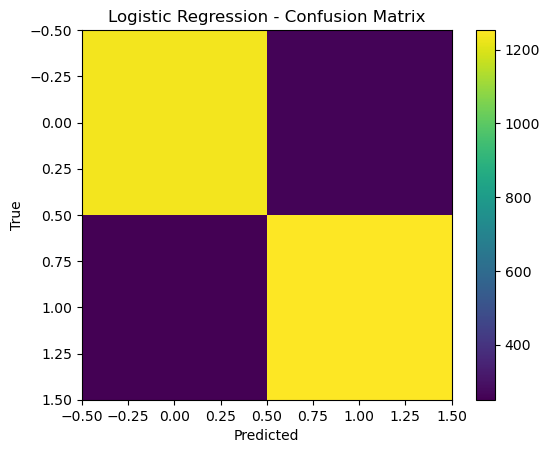

In [18]:
cm_lr = confusion_matrix(y_valid, y_pred_lr)

plt.figure()
plt.imshow(cm_lr)
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()


In [19]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_valid_tfidf)

acc_svm = accuracy_score(y_valid, y_pred_svm)
f1_svm  = f1_score(y_valid, y_pred_svm)

acc_svm, f1_svm


c:\Users\s3udd\anaconda4\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


(0.828, 0.8298153034300791)

In [20]:
print("Logistic Regression -> Accuracy:", acc_lr, "F1:", f1_lr)
print("SVM                -> Accuracy:", acc_svm, "F1:", f1_svm)


Logistic Regression -> Accuracy: 0.8296666666666667 F1: 0.8306264501160093
SVM                -> Accuracy: 0.828 F1: 0.8298153034300791


In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [22]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_train_tfidf)


In [23]:
sil_score = silhouette_score(X_train_tfidf, clusters)
sil_score


0.006795878584737189